In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from utils import ols, mse, rmse, mae, r_squared, adjusted_r_squared

In [124]:
seed = 0
sns.set_theme(
  style='darkgrid'
)
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [125]:
df['sex'] = df['sex'].cat.codes
df['smoker'] = df['smoker'].cat.codes
df['time'] = df['time'].cat.codes
df = pd.get_dummies(data=df, columns=['day'])

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def produce_training_data(df):
  X = df.drop(columns=['tip'])
  y = df['tip'].to_numpy()

  X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.4, random_state=seed)
  X_test, X_validate, y_test, y_validate = train_test_split(X_, y_, test_size=0.5, random_state=seed)

  scaler = StandardScaler()
  X_train_standard = scaler.fit_transform(X_train)
  X_validate_scaled = scaler.transform(X_validate)

  assert X_train_standard.shape == X_train.shape, "Standardized X_train shape does not match X_train's shape"
  assert X_validate_scaled.shape == X_validate.shape, "Standardized X_train shape does not match X_train's shape"
  assert X_train.shape[0] == y_train.shape[0], "X train's shape does not match the y train's shape"


  X_train_standard = np.concat((np.ones(X_train_standard.shape[0]).reshape(-1, 1), X_train_standard), axis=1)
  X_validate_scaled = np.concat((np.ones(X_validate_scaled.shape[0]).reshape(-1, 1), X_validate_scaled), axis=1)

  return X_train_standard, X_validate_scaled, y_train, y_validate


In [127]:
def highlighter(res_df):
    def highlight_single_cell(x):
        color_df = pd.DataFrame('', index=x.index, columns=x.columns)
        mask = res_df.iloc[1:][['MSE', 'RMSE', 'MAE']].reset_index(drop=True) < res_df.iloc[:-1][['MSE', 'RMSE', 'MAE']].reset_index(drop=True)
        mask.index += 1
        color_df[mask] = 'background-color: green'

        mask = res_df.iloc[1:][['R2', 'Adjusted_R2']].reset_index(drop=True) > res_df.iloc[:-1][['R2', 'Adjusted_R2']].reset_index(drop=True)
        mask.index += 1
        color_df[mask] = 'background-color: green'
        return color_df
    return highlight_single_cell

In [128]:
X_train, X_validate, y_train, y_validate = produce_training_data(df)

def compare_features_in_model(all_features):
    features = []
    results = []
    feature_cols = df.drop(columns=['tip']).columns.tolist()

    for feature in all_features:
        features.append(feature)
        cols_idx = [feature_cols.index(f) + 1 for f in features]  # +1 for intercept col
        cols_idx = [0] + cols_idx  # prepend intercept

        X_train_new = X_train[:, cols_idx]
        X_validate_new = X_validate[:, cols_idx]

        weights = ols(X_train_new, y_train)
        pred_ols = X_validate_new @ weights

        results.append({
            "MSE": mse(y_validate, pred_ols),
            "RMSE": rmse(y_validate, pred_ols),
            "MAE": mae(y_validate, pred_ols),
            "R2": r_squared(y_validate, pred_ols),
            "Adjusted_R2": adjusted_r_squared(y_validate, pred_ols, len(features)),
            "Features": " | ".join(features[::-1]),
        })

    res_df = pd.DataFrame(results)
    styled_df = res_df.style.apply(highlighter(res_df), axis=None)
    return res_df, styled_df


all_features = df.columns.drop(['tip'])
res_df, styled_df = compare_features_in_model(all_features)
styled_df

# Adjusted R2 have it's highest value when "total_bill" is the only feature at learning.

,MSE,RMSE,MAE,R2,Adjusted_R2,Features
0,0.832808,0.912583,0.655799,0.611916,0.603659,total_bill
1,0.846215,0.919900,0.658607,0.605668,0.588524,sex | total_bill
2,0.857234,0.925869,0.662831,0.600534,0.573903,smoker | sex | total_bill
3,0.905069,0.951351,0.680968,0.578243,0.539901,time | smoker | sex | total_bill
4,0.902727,0.950120,0.682204,0.579334,0.530420,size | time | smoker | sex | total_bill
5,0.947024,0.973152,0.724401,0.558692,0.495648,day_Thur | size | time | smoker | sex | total_bill
6,0.957686,0.978614,0.723036,0.553724,0.477530,day_Fri | day_Thur | size | time | smoker | sex | total_bill
7,0.948965,0.974148,0.720879,0.557788,0.469345,day_Sat | day_Fri | day_Thur | size | time | smoker | sex | total_bill
8,0.966401,0.983057,0.731680,0.549662,0.445738,day_Sun | day_Sat | day_Fri | day_Thur | size | time | smoker | sex | total_bill


In [129]:
res_df

,MSE,RMSE,MAE,R2,Adjusted_R2,Features
0,0.832808,0.912583,0.655799,0.611916,0.603659,total_bill
1,0.846215,0.919900,0.658607,0.605668,0.588524,sex | total_bill
2,0.857234,0.925869,0.662831,0.600534,0.573903,smoker | sex | total_bill
3,0.905069,0.951351,0.680968,0.578243,0.539901,time | smoker | sex | total_bill
4,0.902727,0.950120,0.682204,0.579334,0.530420,size | time | smoker | sex | total_bill
5,0.947024,0.973152,0.724401,0.558692,0.495648,day_Thur | size | time | smoker | sex | total_...
6,0.957686,0.978614,0.723036,0.553724,0.477530,day_Fri | day_Thur | size | time | smoker | se...
7,0.948965,0.974148,0.720879,0.557788,0.469345,day_Sat | day_Fri | day_Thur | size | time | s...
8,0.966401,0.983057,0.731680,0.549662,0.445738,day_Sun | day_Sat | day_Fri | day_Thur | size ...


[Text(0.5, 0, 'Model Complexity'), Text(0.5, 1.0, 'Error')]

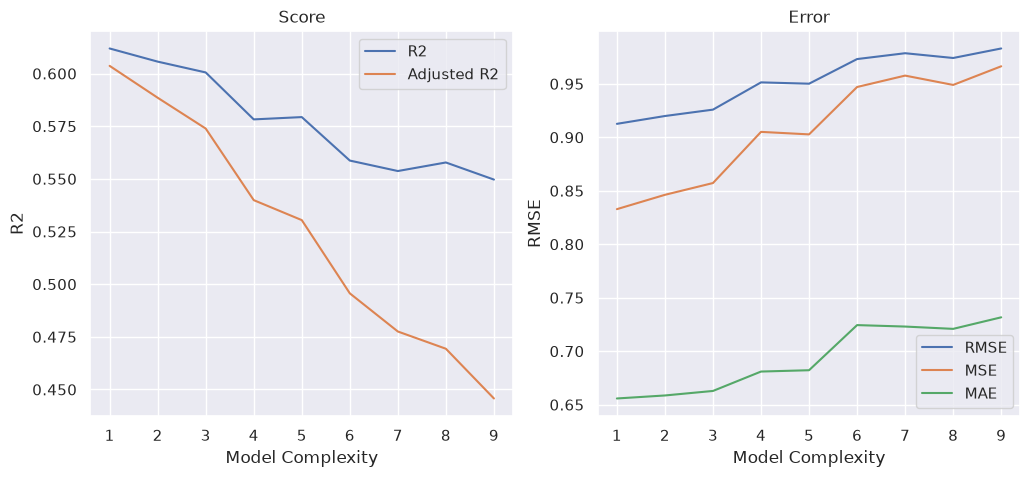

In [130]:
model_complexity = [i + 1 for i in range(len(all_features))]

fig, (ax1 , ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(x=model_complexity, y=res_df['R2'], ax=ax1, label='R2')
sns.lineplot(x=model_complexity, y=res_df['Adjusted_R2'], ax=ax1, label='Adjusted R2')
ax1.set(xlabel="Model Complexity", title='Score')

sns.lineplot(x=model_complexity, y=res_df['RMSE'], ax=ax2, label='RMSE')
sns.lineplot(x=model_complexity, y=res_df['MSE'], ax=ax2, label='MSE')
sns.lineplot(x=model_complexity, y=res_df['MAE'], ax=ax2, label='MAE')
ax2.set(xlabel='Model Complexity', title='Error')